In [1]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

import pandas as pd

import matplotlib.pyplot as plt

In [2]:
def compute_diversity_score(topic_model):
    """
    Compute topic diversity score as the ratio of unique keywords 
    to total keywords across all topics (excluding topic -1).
    """
    topics_ = topic_model.get_topics()
    all_words = [
        word for topic_id, words in topics_.items() if topic_id != -1
        for word, _ in words
    ]
    unique_words = set(all_words)
    return len(unique_words) / len(all_words) if all_words else 0

In [3]:
import re
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

def compute_coherence_score(
    topic_model,
    docs, 
    top_n_words = 5,
    coherence = 'c_v'
):
    """
    Compute topic cohernece score using gensim 
    across all topics (excluding topic -1).
    """

    # Tokenize documents with a clean, custom tokenizer
    def clean_tokenizer(doc):
        return re.findall(r'\b[a-zA-Z][a-zA-Z0-9\-]{2,}\b', doc.lower())

    tokenized_docs = [clean_tokenizer(doc) for doc in docs if isinstance(doc, str) and doc.strip()]

    # Build gensim Dictionary
    dictionary = Dictionary(tokenized_docs)

    # Restrict to vectorizer's vocabulary
    vectorizer = topic_model.vectorizer_model
    vocab = set(vectorizer.get_feature_names_out())

    # Extract top words from each topic, filtering out -1
    topic_words = []
    for topic_id in topic_model.get_topic_info().Topic.tolist():
        if topic_id == -1:
            continue
        words = [w for w, _ in topic_model.get_topic(topic_id)[:top_n_words]]
        filtered = [w for w in words if w in vocab and w in dictionary.token2id]
        if filtered:
            topic_words.append(filtered)

    # Compute coherence
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence=coherence
    )

    return coherence_model.get_coherence()

In [4]:
from collections import Counter

def topic_model_analysis(topic_model, docs):
    """
    Analyze the BERTopic model:
    - Reports number of outliers (topic -1)
    - Computes topic diversity score
    - Computes topic cohernece score
    - Prints topic summary table
    """
    # Get topic assignment info for each document
    df_info = topic_model.get_document_info(docs)
    
    # Outlier analysis
    total_docs = len(df_info)
    num_outliers = (df_info['Topic'] == -1).sum()
    outlier_ratio = num_outliers / total_docs

    print(f"Total documents: {total_docs}\n")
    print(f"Documents assigned to topic -1: {num_outliers} ({outlier_ratio:.2%})\n")

    # Topic diversity score
    diversity_score = compute_diversity_score(topic_model)
    print(f"Topic Diversity Score: {diversity_score:.4f}\n")

    coherence_score = compute_coherence_score(topic_model, docs)
    print(f"Topic Coherence Score: {coherence_score:.4f}\n")

    # Topic summary
    print("Topic Summary:")
    print(topic_model.get_topic_info())

In [5]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [7]:
embeddings = np.load('../Model/emb_all-MiniLM-L6-v2.npy')

description_text = pd.read_csv('../Output/london_app_doc.csv')
docs = description_text['description'].tolist()

stop_words_ = ['of', 'and', 'to', 'with', 'the', 'at', 'into', 'from', 'in', 'for', 'as', 'on'] + ["an"]

vectorizer_model = CountVectorizer(
    stop_words=stop_words_,
    ngram_range=(1,2)  
)

topic_model = BERTopic.load("../Model/bertopic_mcs=10_ms=10_nn=15_nc=5_md=0.0_nr=1,2.pkl")

In [8]:
topic_model_analysis(topic_model, docs)

Total documents: 113938

Documents assigned to topic -1: 48749 (42.79%)

Topic Diversity Score: 0.5069

Topic Coherence Score: 0.9880

Topic Summary:
      Topic  Count                                               Name  \
0        -1  48749                     -1_ground_building_floor_units   
1         0   2796  0_maisonette_floor maisonette_bedroom maisonet...   
2         1   1957        1_dormer_rear dormer_dormer extension_slope   
3         2   1954  2_mansard_mansard roof_erection mansard_roof e...   
4         3   1000  3_alteration conversion_alteration_together co...   
...     ...    ...                                                ...   
1170   1169     10  1169_extensions formation_conversion form_acce...   
1171   1170     10  1170_property four_above property_conversion p...   
1172   1171     10  1171_accessed mount_terraces sheds_sheds three...   
1173   1172     10  1172_front second_elevation timber_levels fron...   
1174   1173     10   1173_site by_by erection_s

In [11]:
def topic_number_analysis(docs, topic_nums):
    """
    Reduce topics to various numbers and plot the custom Topic Diversity Score.
    Parameters:
        topic_model (BERTopic): Pretrained BERTopic model.
        docs (List[str]): List of text documents.
        topic_nums (List[int]): List of topic numbers to test.
    """
    diversity_scores = []
    coherence_scores = []

    for n in topic_nums:
        reduced_model = BERTopic.load("../Model/bertopic_mcs=10_ms=10_nn=15_nc=5_md=0.0_nr=1,2.pkl")
        reduced_model.reduce_topics(docs, nr_topics=n)
        reduced_model.update_topics(docs, vectorizer_model=vectorizer_model)

        diversity = compute_diversity_score(reduced_model)
        coherence = compute_coherence_score(reduced_model, docs)

        diversity_scores.append(diversity)
        coherence_scores.append(coherence)

        print(f"Reduced to {n} topics → Diversity: {diversity:.4f}, Coherence: {coherence:.4f}")

    # Plot both metrics
    plt.figure(figsize=(10, 6))
    plt.plot(topic_nums, diversity_scores, label='Diversity Score', marker='o')
    plt.plot(topic_nums, coherence_scores, label='Coherence Score', marker='s')
    plt.xlabel("Number of Topics", fontsize=12, fontweight='bold')
    plt.ylabel("Score", fontsize=12, fontweight='bold')
    plt.title("Topic Diversity vs. Coherence Score", fontsize=16, fontweight='bold', pad=20)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Reduced to 10 topics → Diversity: 0.8111, Coherence: 0.8454
Reduced to 20 topics → Diversity: 0.7789, Coherence: 0.8458
Reduced to 30 topics → Diversity: 0.7414, Coherence: 0.8673
Reduced to 40 topics → Diversity: 0.7513, Coherence: 0.8728
Reduced to 50 topics → Diversity: 0.7449, Coherence: 0.8603
Reduced to 60 topics → Diversity: 0.7305, Coherence: 0.8657
Reduced to 70 topics → Diversity: 0.7319, Coherence: 0.8696
Reduced to 80 topics → Diversity: 0.7165, Coherence: 0.8777
Reduced to 90 topics → Diversity: 0.7135, Coherence: 0.8940
Reduced to 100 topics → Diversity: 0.6949, Coherence: 0.9075
Reduced to 200 topics → Diversity: 0.6603, Coherence: 0.9294
Reduced to 300 topics → Diversity: 0.6207, Coherence: 0.9455
Reduced to 400 topics → Diversity: 0.5995, Coherence: 0.9583
Reduced to 500 topics → Diversity: 0.5828, Coherence: 0.9689
Reduced to 600 topics → Diversity: 0.5693, Coherence: 0.9749
Reduced to 700 topics → Diversity: 0.5504, Coherence: 0.9799
Reduced to 800 topics → Diversity

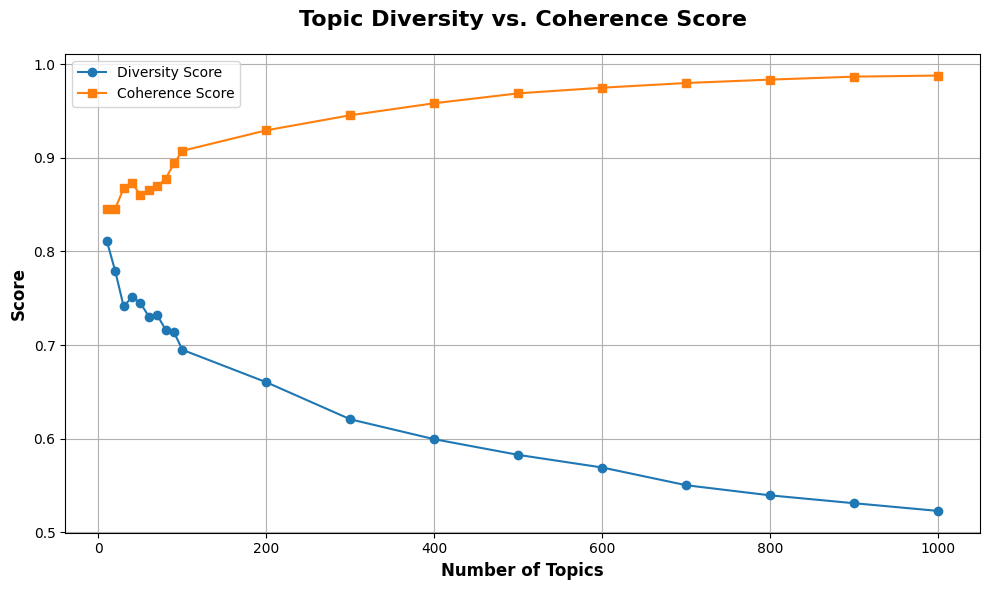

In [12]:
topic_number_analysis(docs,
                      topic_nums=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])

In [13]:
topic_model.reduce_topics(docs, nr_topics=90)
topic_model.update_topics(docs, vectorizer_model=vectorizer_model)

In [14]:
topic_model_analysis(topic_model, docs)

Total documents: 113938

Documents assigned to topic -1: 48749 (42.79%)

Topic Diversity Score: 0.7135

Topic Coherence Score: 0.8940

Topic Summary:
    Topic  Count                                               Name  \
0      -1  48749                      -1_floor_storey_rear_existing   
1       0  14977                     0_conversion_rear_single_flats   
2       1  10326  1_demolition_demolition existing_existing_buil...   
3       2   4883         2_mansard_mansard roof_roof_roof extension   
4       3   4233          3_erection_parking_storey_storey building   
..    ...    ...                                                ...   
85     84     13  84_convert_convert existing_convert 1bed_exist...   
86     85     13   85_units convert_flat units_convert flat_convert   
87     86     12              86_b1 flat_flat change_a1 flat_use b1   
88     87     12        87_hmo_up occupants_occupants_roofslope use   
89     88     11         88_flat use_c3 change_use class_b1a create  

In [15]:
reduced_embeddings = UMAP(n_neighbors=10, n_components=2,
                          min_dist=0.0, metric='cosine', random_state=42).fit_transform(embeddings)

In [16]:
topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings,
                                hide_document_hover=True, hide_annotations=True)

In [ ]:
topics_reduced, probs_reduced = topic_model.transform(docs)

In [ ]:
description_text_copy = pd.read_csv('../Output/london_app_doc.csv')

description_text_copy['topic'] = topics_reduced
description_text_copy['probabilities'] = probs_reduced.tolist()

description_text_copy.to_csv("../Output/NLP Output/feature_extraction_reduced_90.csv", index=False)

topic_info = topic_model.get_topic_info()

topic_info.to_csv("../Output/NLP Output/topic_info_reduced_90.csv", index=False)